# Handling Outliers — The IQR Method

The Z-score method (previous notebook) assumes a roughly normal distribution — `placement_exam_marks` isn't one (it's visibly right-skewed). The **IQR (Interquartile Range)** method doesn't assume normality at all, which makes it the right tool for this column specifically.

## 1. Setup and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/kaggle/input/datasets/muhammadzafranai/placements/placement.csv')

In [3]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


### Confirming This Column Needs a Different Method Than Z-Score

*(`sns.distplot()` removed — replaced with `sns.histplot(kde=True)`.)*

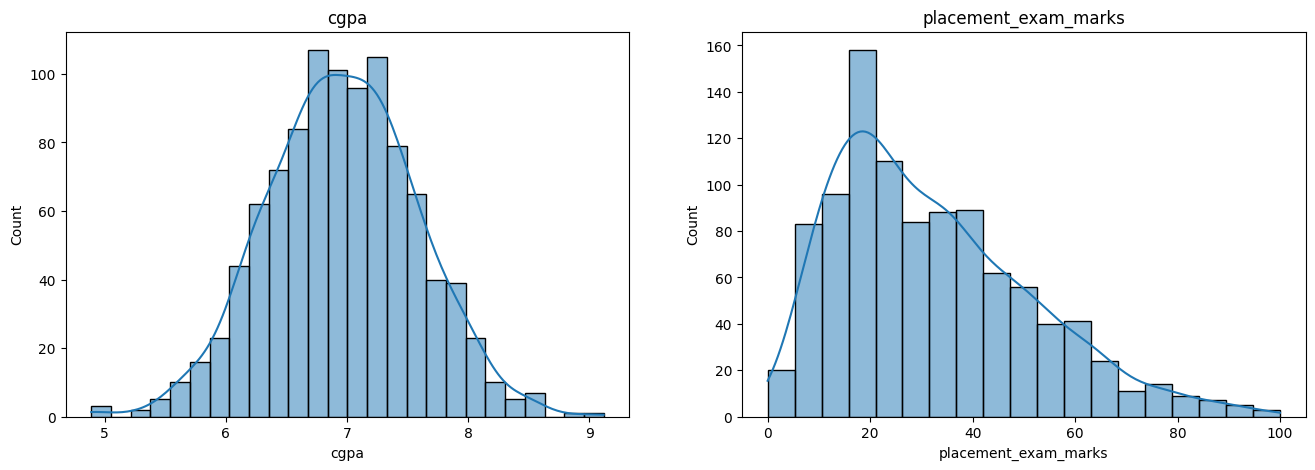

In [4]:
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True)
plt.title('cgpa')

plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('placement_exam_marks')

plt.show()


In [5]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

*(`sns.boxplot()` also needs the column passed as `x=`, not positionally, on current seaborn.)*

In [6]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

<Axes: xlabel='placement_exam_marks'>

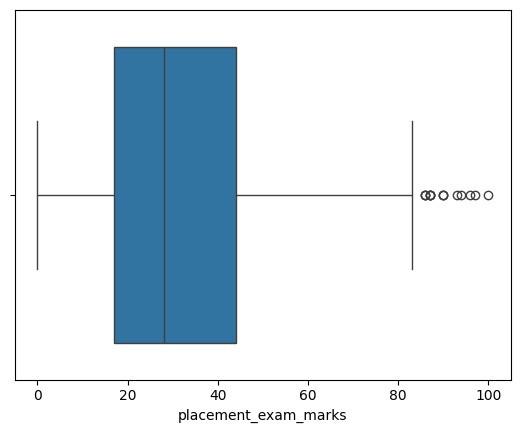

In [7]:
sns.boxplot(x=df['placement_exam_marks'])


## 2. Computing the IQR Boundaries

`percentile25`/`percentile75` mark the middle 50% of the data; their difference is the **IQR**. The classic rule: anything beyond `1.5 × IQR` past either percentile counts as an outlier — this threshold is based purely on the data's own spread, with **no normality assumption** at all, unlike the Z-score method.

In [8]:
# Finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [9]:
percentile75

np.float64(44.0)

In [10]:
percentile25

np.float64(17.0)

In [11]:
iqr = percentile75 - percentile25

In [12]:
iqr

np.float64(27.0)

In [13]:
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

In [14]:
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 84.5
Lower limit -23.5


## Finding Outliers

In [15]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [16]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


## Trimming

In [17]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [18]:
new_df.shape

(985, 3)

### Visual Before/After Comparison

Distribution and boxplot, side by side, before vs. after trimming — the long right tail and high outlier dots should both be noticeably reduced.

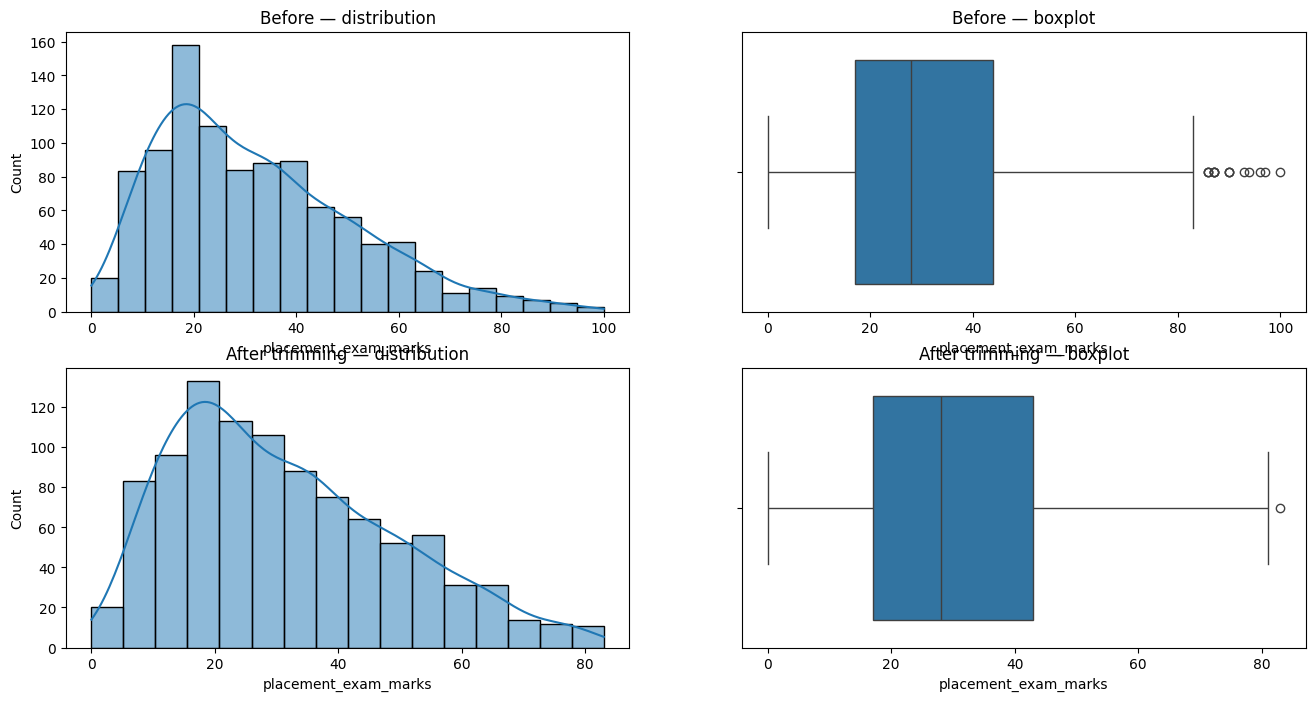

In [19]:
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Before — distribution')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['placement_exam_marks'])
plt.title('Before — boxplot')

plt.subplot(2, 2, 3)
sns.histplot(new_df['placement_exam_marks'], kde=True)
plt.title('After trimming — distribution')

plt.subplot(2, 2, 4)
sns.boxplot(x=new_df['placement_exam_marks'])
plt.title('After trimming — boxplot')

plt.show()


## Capping

## 3. Capping Instead of Trimming

Same trade-off as the Z-score notebook: capping keeps every row, just pulling extreme values in to the boundary rather than dropping them.

In [20]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

### ⚠️ Not Real Code — A Syntax Reminder Left in by Mistake

`np.where(condtion,true,false)` isn't valid Python — `condtion` and `true`/`false` were never defined as variables anywhere. This line looks like a note-to-self about `np.where()`'s argument order (`condition, value_if_true, value_if_false`) that got left in as if it were a runnable cell. Removed as code; the actual working call is the cell above.

In [21]:
new_df_cap.shape

(1000, 3)

### Visual Before/After Comparison — Capping

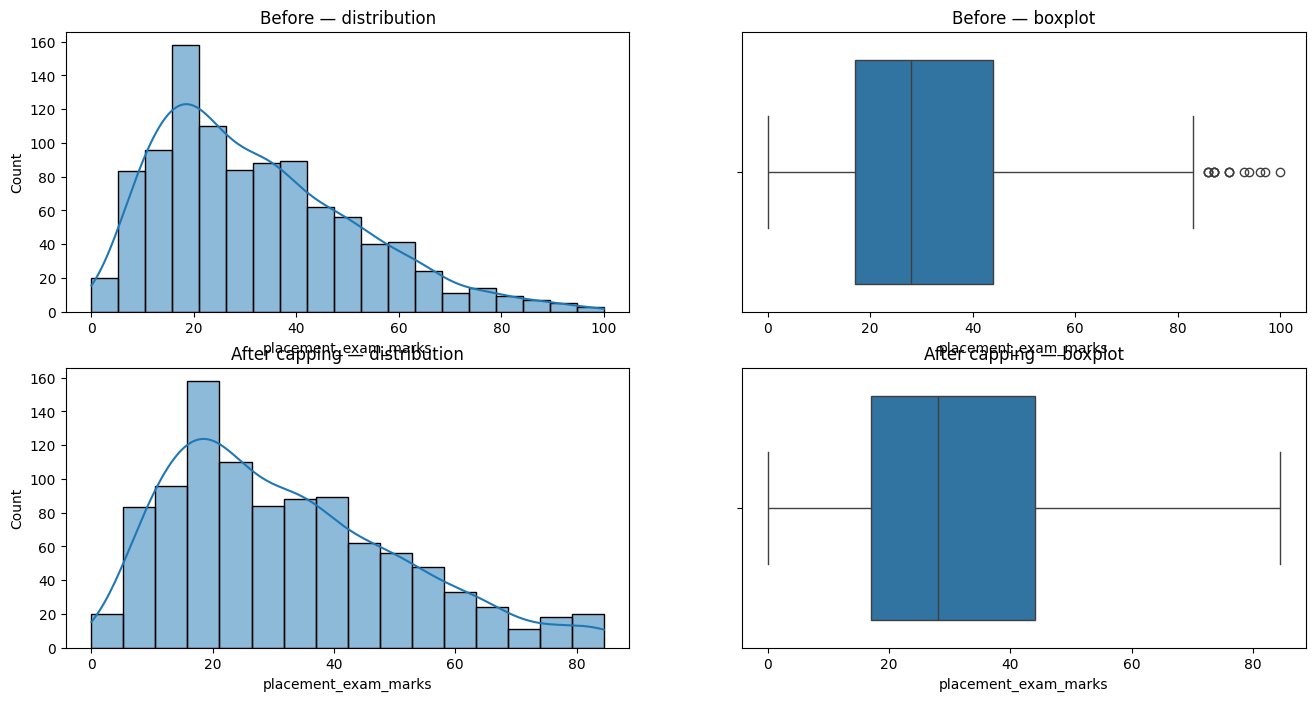

In [22]:
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Before — distribution')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['placement_exam_marks'])
plt.title('Before — boxplot')

plt.subplot(2, 2, 3)
sns.histplot(new_df_cap['placement_exam_marks'], kde=True)
plt.title('After capping — distribution')

plt.subplot(2, 2, 4)
sns.boxplot(x=new_df_cap['placement_exam_marks'])
plt.title('After capping — boxplot')

plt.show()


## Summary

| Task | Method |
|---|---|
| Compute the IQR | `Q3 - Q1` via `.quantile(0.75)` / `.quantile(0.25)` |
| Compute outlier boundaries | `Q1 - 1.5*IQR`, `Q3 + 1.5*IQR` |
| Trim | `df[df[col] < upper]` (and `> lower` if needed) |
| Cap | `np.where(df[col] > upper, upper, np.where(df[col] < lower, lower, df[col]))` |

### IQR vs. Z-score
IQR makes no assumption about the column's shape — the right default for skewed data like this one. Z-score (previous notebook) is more standard for genuinely normal-looking columns, and is simpler to compute when that assumption actually holds.